In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [138]:
#importo base 2005
from google.colab import files; uploaded=files.upload()  # elegí T105.dta
df_05= pd.read_stata("Individual_t105.dta")
df_05

Saving Individual_t105.dta to Individual_t105 (3).dta


,CODUSU,nro_hogar,componente,h15,ano4,trimestre,region,mas_500,aglomerado,pondera,...,deccfr,ideccfr,rdeccfr,gdeccfr,pdeccfr,adeccfr,pj1_1,pj2_1,pj3_1,idimpp
0,125098,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1017.0,...,08,,07,08,,05,0.0,0.0,0.0,00000
1,125188,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,40020
2,125188,1.0,2.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,00000
3,125188,1.0,3.0,0.0,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1062.0,...,02,,02,02,,01,0.0,0.0,0.0,00000
4,125242,1.0,1.0,Sí,2005.0,1er. Trimestre,Gran Buenos Aires,S,Ciudad de Buenos Aires,1103.0,...,09,,09,09,,07,0.0,0.0,0.0,00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47025,288015,1.0,3.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,129.0,...,09,10,09,,10,07,0.0,0.0,0.0,00000
47026,288015,1.0,4.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,129.0,...,09,10,09,,10,07,0.0,0.0,0.0,00000
47027,288294,1.0,1.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,107.0,...,10,10,09,,10,09,0.0,0.0,0.0,00000
47028,288294,1.0,2.0,Sí,2005.0,1er. Trimestre,Patagónica,N,Ushuaia - Río Grande,107.0,...,10,10,09,,10,09,0.0,0.0,0.0,00000


In [139]:
#importo base 2025
from google.colab import files # elegir 2025
uploaded = files.upload()
fname = list(uploaded.keys())[0]

df_25 = pd.read_excel(fname)  # o pd.read_excel(fname, sheet_name="NombreDeHoja")
df_25.head()

Saving usu_individual_T125 (1).xlsx to usu_individual_T125 (1) (2).xlsx


,CODUSU,ANO4,TRIMESTRE,NRO_HOGAR,COMPONENTE,H15,REGION,MAS_500,AGLOMERADO,PONDERA,...,V21_03_M,V22_01_M,V22_02_M,V22_03_M,P_DECCF,P_RDECCF,P_GDECCF,P_PDECCF,P_IDECCF,P_ADECCF
0,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,2,1,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
1,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,3,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
2,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,4,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
3,TQRMNOVQVHJOLOCDEFKID00875778,2025,1,1,5,0,43,S,4,927,...,0,0,0,0,3.0,2.0,3.0,NaN,3.0,2.0
4,TQRMNOUPQHLOLOCDEFKID00851757,2025,1,1,1,1,43,S,4,1294,...,0,0,0,0,3.0,3.0,3.0,NaN,3.0,3.0


# Base homogénea

In [140]:
#Una vez visto el formato de cada variable, pasamos el formato de las de 2005, igual al de 2025.
import pandas as pd
import numpy as np
from pandas.api.types import is_integer_dtype, is_float_dtype


# 0) Copia y normalizo nombres

df2005 = df_05.copy()
df2025 = df_25.copy()

# renombro columnas de 2005 a MAYÚSCULAS para alinearlas con 2025
ren_2005 = {c: c.upper() for c in df2005.columns}
df2005 = df2005.rename(columns=ren_2005)


# 1) dtypes objetivo (2025)

target_dtypes = df2025.dtypes  #yo quiero todo igual al 2025.

# columnas comunes (por nombre ya en mayúsculas)
comunes = sorted(set(df2005.columns) & set(df2025.columns))


# 2) Mapeos especiales (texto a códigos)

SPECIAL_MAPS = {
    "CH04": {  # sexo: texto a 1/2
        "1": 1, "varon": 1, "varón": 1, "hombre": 1, "m": 1, "masculino": 1,
        "2": 2, "mujer": 2, "f": 2, "femenino": 2
    },
}

def apply_special_map(series: pd.Series, col: str) -> pd.Series:
    if col not in SPECIAL_MAPS:
        return series
    # normalizo a string-lower y mapeo
    m = SPECIAL_MAPS[col]
    s = series.astype("string").str.strip().str.lower()
    return s.map(m)# 3) Conversión columna a columna

def convert_to_target(s: pd.Series, target_dtype) -> pd.Series:
    """
    Convierte s al dtype de 2025:
      - int64  -> numérico y luego Int64 (si no hay NaN, baja a int64)
      - float64-> numérico float
      - object -> a object/string
      - category en 2005 se elimina (paso intermedio a object)
    """
    # sacar 'category' si viene así de 2005
    if str(s.dtype) == "category":
        s = s.astype("object")

    # int objetivo
    if is_integer_dtype(target_dtype):
        s_num = pd.to_numeric(s, errors="coerce")
        out = s_num.round().astype("Int64")
        # si no hay NA, convierto a numpy int64 puro (opcional)
        if out.isna().sum() == 0:
            out = out.astype("int64")
        return out

    # float objetivo
    if is_float_dtype(target_dtype):
        return pd.to_numeric(s, errors="coerce").astype("float64")

    # object objetivo
    return s.astype("object")

# hago una copia donde ir dejando las columnas ya convertidas
df2005_conv = df2005.copy()

log = []  # para ver qué se hizo

for col in comunes:
    tgt = target_dtypes[col]

    # 1) mapeo especial si aplica (por ej. CH04)
    mapped = apply_special_map(df2005_conv[col], col)
    if col in SPECIAL_MAPS:
        # si hubo mapeo, reemplazo donde haya valor mapeado
        df2005_conv[col] = mapped.where(mapped.notna(), df2005_conv[col])

    # 2) convierto al dtype de 2025
    before = str(df2005_conv[col].dtype)
    df2005_conv[col] = convert_to_target(df2005_conv[col], tgt)
    after = str(df2005_conv[col].dtype)

    log.append((col, before, str(tgt), after))


# 4) Resumen de el pase de variable

resumen = pd.DataFrame(log, columns=["columna", "dtype_2005_origen", "dtype_2025_objetivo", "dtype_2005_final"])
resumen = resumen.sort_values("columna").reset_index(drop=True)

print("Conversión realizada sobre", len(comunes), "columnas comunes.")
display(resumen.head(20))

# df2005_conv es la  base de 2005 armonizada a los formatos de 2025
# (mismos nombres en MAYÚSCULA y dtypes compatibles con 2025)
#ahora que esto funciona, vamos a trabajr con:
#df 2005 = df2005_conv
#df 2025 = df_T125

Conversión realizada sobre 168 columnas comunes.


,columna,dtype_2005_origen,dtype_2025_objetivo,dtype_2005_final
0,ADECCFR,object,int64,int64
1,ADECIFR,object,int64,int64
2,ADECINDR,object,int64,int64
3,ADECOCUR,object,int64,Int64
4,AGLOMERADO,category,int64,Int64
5,ANO4,float64,int64,int64
6,CAT_INAC,category,int64,Int64
7,CAT_OCUP,category,int64,Int64
8,CH03,category,int64,Int64
9,CH04,int64,int64,int64


In [141]:
# 5) Alinear columnas y juntar

# columnas únicas a cada dataframe
cols_2005_unicas = sorted(set(df2005_conv.columns) - set(comunes))
cols_2025_unicas = sorted(set(df2025.columns) - set(comunes))


# creo copias para no modificar los df originales
df2005_aligned = df2005_conv.copy()
df2025_aligned = df2025.copy()


# agrego columnas únicas de 2025 a 2005 (con NaN)
for col in cols_2025_unicas:
    df2005_aligned[col] = pd.NA  # o pd.NA o np.nan según el dtype

# agrego columnas únicas de 2005 a 2025 (con NaN)
for col in cols_2005_unicas:
    df2025_aligned[col] = pd.NA # o pd.NA o np.nan según el dtype


# reordeno columnas para que estén en el mismo orden
df2005_aligned = df2005_aligned[sorted(df2005_aligned.columns)]
df2025_aligned = df2025_aligned[sorted(df2025_aligned.columns)]


# verifico que tengan las mismas columnas y en el mismo orden
if not df2005_aligned.columns.equals(df2025_aligned.columns):
    print("Error: Las columnas no coinciden después de alinear.")
else:
    print("Columnas alineadas correctamente.")
    # concateno
    base_final = pd.concat([df2005_aligned, df2025_aligned], ignore_index=True)
    print("Bases concatenadas. Tamaño de base_final:", base_final.shape)

# Display a random sample of the final dataframe
display(base_final.sample(5))

Columnas alineadas correctamente.


/tmp/ipython-input-178140345.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_final = pd.concat([df2005_aligned, df2025_aligned], ignore_index=True)
/tmp/ipython-input-178140345.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  base_final = pd.concat([df2005_aligned, df2025_aligned], ignore_index=True)
/tmp/ipython-input-178140345.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude 

Bases concatenadas. Tamaño de base_final: (92455, 243)


,ADECCFR,ADECIFR,ADECINDR,ADECOCUR,AGLOMERADO,ANO4,CAT_INAC,CAT_OCUP,CH03,CH04,...,V2_03_M,V2_M,V3_M,V4_M,V5_01_M,V5_02_M,V5_03_M,V5_M,V8_M,V9_M
42360,1,2,0,<NA>,<NA>,2005,<NA>,0,<NA>,2,...,<NA>,0.0,0,0,<NA>,<NA>,<NA>,0.0,0,0
36604,2,4,0,<NA>,<NA>,2005,<NA>,0,<NA>,1,...,<NA>,0.0,0,0,<NA>,<NA>,<NA>,0.0,0,0
78726,12,12,0,0,9,2025,0,3,1,1,...,0,NaN,0,0,0,0,0,NaN,0,0
3814,3,4,0,<NA>,<NA>,2005,<NA>,0,<NA>,1,...,<NA>,0.0,0,0,<NA>,<NA>,<NA>,0.0,0,0
69514,6,7,7,6,33,2025,0,2,1,1,...,0,NaN,0,0,0,0,0,NaN,0,0


# *Parte I* : Creación de variables, histogramas, kernels y resumen de la base de datos final


# 1) PUNTO 1


In [ ]:
#1) Cree la variable “edad2” definida como edad2
#(edad al cuadrado).
#Presente un histograma de la variable edad en un panel A, y a la par una
#distribución de kernels para los pobres y no pobres en un panel B (esto
#es, son dos líneas de kernel en este segundo panel). Comente brevemente
#la distribución de edades en estos dos paneles (3-4 oraciones).


In [142]:
#Crear edad2 en base_final

if "CH06" in base_final.columns:
    base_final["edad2"] = base_final["CH06"]**2
    print(f"Variable 'edad2' creada exitosamente en base_final.")
    display(base_final[["CH06", "edad2"]].sample(10))
else:
    print(f"La columna 'CH06' no se encuentra en base_final.")

Variable 'edad2' creada exitosamente en base_final.


/tmp/ipython-input-1878021708.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_final["edad2"] = base_final["CH06"]**2


,CH06,edad2
48842,30,900
45933,17,289
81920,38,1444
25618,59,3481
24324,14,196
46138,5,25
86096,54,2916
87905,27,729
82147,51,2601
37183,13,169


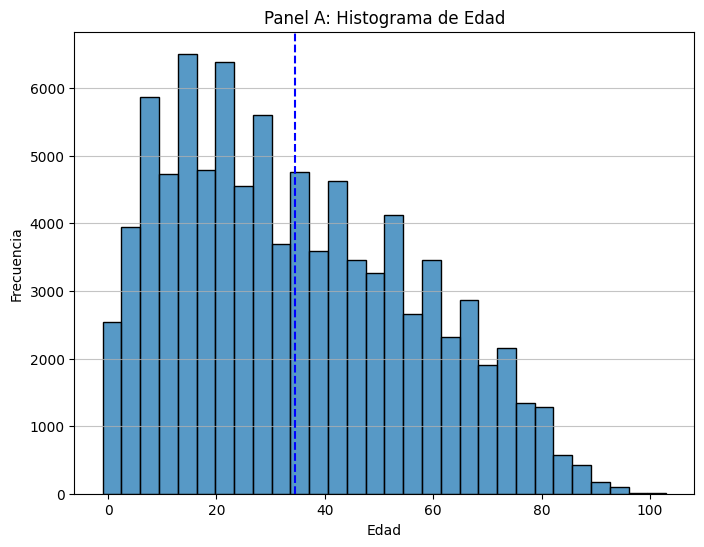

In [143]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a histogram of the 'CH06' (edad) variable
plt.figure(figsize=(8, 6))
sns.histplot(data=base_final, x='CH06', bins=30)

plt.title('Panel A: Histograma de Edad')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)

edad_promedio=base_final["CH06"].mean()
plt.axvline(x=edad_promedio, color='blue', linestyle='--', label=f"Edad promedio = {edad_promedio:.2f}")

plt.show()

In [ ]:
##### Distribución de kernels para los pobres y no pobres
#meto todo lo de pobreza (tp1)


In [144]:
import pandas as pd

# Asegurar que ESTADO sea numérico (si quedó como texto "0", lo convierte)
base_final["ESTADO"] = pd.to_numeric(base_final["ESTADO"], errors="coerce")

# Ver si aparecen 0 o NaN
print("¿Hay 0 en ESTADO? ", (base_final["ESTADO"] == 0).any())
print("¿Hay NaN en ESTADO?", base_final["ESTADO"].isna().any())

# Conteo total de no respuesta (0 o NaN)
mask_no_resp = base_final["ESTADO"].isna() | (base_final["ESTADO"] == 0)
n_total = len(base_final)
n_no    = mask_no_resp.sum()
print(f"\nNo respondieron condición de actividad (0 o NaN): {n_no} de {n_total}  ({n_no/n_total:.1%})")

# Detalle por año
if "ANO4" in base_final.columns:
    resumen = (base_final.assign(no_resp=mask_no_resp)
                          .groupby("ANO4")["no_resp"]
                          .agg(no_resp="sum", total="size"))
    resumen["pct"] = 100 * resumen["no_resp"] / resumen["total"]
    print("\nPor año (2005 vs 2025):\n", resumen)


print(base_final["ESTADO"].value_counts(dropna=False).sort_index()) # Mirar los valores que tiene ESTADO

¿Hay 0 en ESTADO?  True
¿Hay NaN en ESTADO? True

No respondieron condición de actividad (0 o NaN): 47105 de 92455  (50.9%)

Por año (2005 vs 2025):
       no_resp  total       pct
ANO4                          
2005    47030  47030     100.0
2025       75  45425  0.165107
ESTADO
0          75
1       20076
2        1381
3       18866
4        5027
<NA>    47030
Name: count, dtype: Int64


In [145]:
# Asegurar numérico
if "ITF" in base_final.columns:
    base_final["ITF"] = pd.to_numeric(base_final["ITF"], errors="coerce")
else:
    print("Warning: 'ITF' column not found in base_final.")


# respondieron ITF (1 si ITF>0 and not NaN; 0 if ITF==0 or NaN) ===
# Using base_final directly
base_final["respondio_ITF"] = np.where(base_final["ITF"].notna() & (base_final["ITF"] > 0), 1, 0).astype("int8")


#  Bases pedidas por consigna ===
respondieron  = base_final.query("respondio_ITF == 1").copy()
norespondieron = base_final.query("respondio_ITF == 0").copy()



/tmp/ipython-input-681789565.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  base_final["respondio_ITF"] = np.where(base_final["ITF"].notna() & (base_final["ITF"] > 0), 1, 0).astype("int8")


In [ ]:
#A PARTIR DE ACA USO LA BASE "RESPONDIERON" YA QUE SON LOS Q PODES HACER LOS ANALISIS

In [146]:
#IMPORTO LA TABLA DE ADULTOS EQUIVALENTE

from google.colab import files
uploaded = files.upload()
fname = list(uploaded.keys())[0]

def cargar_tabla_adulto_equiv_simple(path="tabla_adulto_equiv.xlsx", verbose=True):
    # Leer todo como string para no “romper” nada al principio
    raw = pd.read_excel(path, header=None, dtype=str)

    # 1) Detectar automáticamente la fila y las 3 columnas correctas: Edad | Mujeres | Varones
    hdr_row = None
    col_edad = col_muj = col_var = None
    for r in range(len(raw)):
        row = raw.iloc[r].astype(str).str.strip().str.lower()
        for c in range(len(row) - 2):
            a, b, d = row.iloc[c], row.iloc[c+1], row.iloc[c+2]
            if a == "edad" and "mujer" in b and ("varon" in d or "varón" in d):
                hdr_row, col_edad, col_muj, col_var = r, c, c+1, c+2
                break
        if hdr_row is not None:
            break

    if hdr_row is None:
        raise ValueError("No encontré encabezados 'Edad | Mujeres | Varones' en el archivo.")

    if verbose:
        print(f"Encabezado detectado en fila {hdr_row} | columnas: EDAD={col_edad}, MUJERES={col_muj}, VARONES={col_var}")

    # 2) Quedarnos con esas 3 columnas desde la fila siguiente
    tbl = raw.iloc[hdr_row+1:, [col_edad, col_muj, col_var]].copy()
    tbl.columns = ["EDAD", "MUJERES", "VARONES"]

    # 3) Limpiar EDAD (espacios raros) y pasar equivalencias a número (coma -> punto)
    tbl["EDAD"] = (tbl["EDAD"].fillna("")
                             .str.replace("\xa0", " ", regex=False)
                             .str.strip()
                             .str.replace(r"\s+", " ", regex=True))

    for c in ["MUJERES", "VARONES"]:
        s = tbl[c].fillna("").str.replace("\xa0", " ", regex=False).str.strip()
        s = s.str.replace(",", ".", regex=False)  # por si vienen con coma decimal
        tbl[c] = pd.to_numeric(s, errors="coerce")

    # 4) Quitar filas basura (todas NaN o textos tipo 'Ejemplos...', 'Fuente...')
    basura = tbl["EDAD"].str.lower().str.contains("ejemplo|fuente|indec", na=False)
    todo_nan = tbl[["MUJERES","VARONES"]].isna().all(axis=1)
    tbl = tbl[~(basura | todo_nan)].reset_index(drop=True)

    return tbl

# === USO ===
adulto_equiv = cargar_tabla_adulto_equiv_simple(fname) # Use the uploaded file name

# 1) quitar la cabecera repetida
mask_midheader = adulto_equiv["EDAD"].astype(str).str.strip().str.lower().eq("edad")

# 2) quitar filas “basura” donde MUJERES y VARONES son ambos NaN
mask_allnan = adulto_equiv[["MUJERES","VARONES"]].isna().all(axis=1)

adulto_equiv = adulto_equiv[~(mask_midheader | mask_allnan)].reset_index(drop=True)


print(adulto_equiv)

Saving tabla_adulto_equiv.xlsx to tabla_adulto_equiv (3).xlsx
Encabezado detectado en fila 3 | columnas: EDAD=0, MUJERES=1, VARONES=2
              EDAD  MUJERES  VARONES
0   Menor de 1 año     0.35     0.35
1             1año     0.37     0.37
2           2 años     0.46     0.46
3           3 años     0.51     0.51
4           4 años     0.55     0.55
5           5 años     0.60     0.60
6           6 años     0.64     0.64
7           7 años     0.66     0.66
8           8 años     0.68     0.68
9           9 años     0.69     0.69
10         10 años     0.70     0.79
11         11 años     0.72     0.82
12         12 años     0.74     0.85
13         13 años     0.76     0.90
14         14 años     0.76     0.96
15         15 años     0.77     1.00
16         16 años     0.77     1.03
17         17 años     0.77     1.04
18    18 a 29 años     0.76     1.02
19    30 a 45 años     0.77     1.00
20    46 a 60 años     0.76     1.00
21    61 a 75 años     0.67     0.83
22  más de 75 a

In [147]:
# Merge base "respondieron" with adulto_equiv to get the 'adulto_equiv' value for each person
# Need to prepare adulto_equiv for merging by creating age ranges and mapping sex codes
def map_age_to_range(age):
    # Ensure age is treated as numeric, handle potential NaNs or conversion errors
    if pd.isna(age):
        return np.nan
    try:
        age = int(age)
    except ValueError:
        return np.nan # Handle cases where conversion to int fails

    if age < 1:
        return "Menor de 1 año"
    elif age == 1:
        return "1año"
    elif age == 2:
        return "2 años"
    elif age == 3:
        return "3 años"
    elif age == 4:
        return "4 años"
    elif age == 5:
        return "5 años"
    elif age == 6:
        return "6 años"
    elif age == 7:
        return "7 años"
    elif age == 8:
        return "8 años"
    elif age == 9:
        return "9 años"
    elif age == 10:
        return "10 años"
    elif age == 11:
        return "11 años"
    elif age == 12:
        return "12 años"
    elif age == 13:
        return "13 años"
    elif age == 14:
        return "14 años"
    elif age == 15:
        return "15 años"
    elif age == 16:
        return "16 años"
    elif age == 17:
        return "17 años"
    elif 18 <= age <= 29:
        return "18 a 29 años"
    elif 30 <= age <= 45:
        return "30 a 45 años"
    elif 46 <= age <= 60:
        return "46 a 60 años"
    elif 61 <= age <= 75:
        return "61 a 75 años"
    elif age > 75:
        return "más de 75 años"
    else:
        return np.nan

# asegurar que edad es numerico
respondieron['CH06'] = pd.to_numeric(respondieron['CH06'], errors='coerce')

respondieron['EDAD_RANGO'] = respondieron['CH06'].apply(map_age_to_range)

# Mapeo sexo en adulto_equiv
respondieron['SEXO_COL'] = respondieron['CH04'].map({1: 'VARONES', 2: 'MUJERES'})

# Mergeas para tener la variable de adulto queivalente
respondieron = pd.merge(respondieron, adulto_equiv, left_on='EDAD_RANGO', right_on='EDAD', how='left')


# Select the correct adulto_equiv value based on sex
respondieron['adulto_equiv'] = respondieron.apply(lambda row: row[row['SEXO_COL']] if pd.notna(row['SEXO_COL']) and pd.notna(row['EDAD_RANGO']) else np.nan, axis=1)

# Drop the intermediate columns used for merging
respondieron = respondieron.drop(columns=['EDAD_RANGO', 'SEXO_COL', 'EDAD', 'MUJERES', 'VARONES'], errors='ignore')

# Recalculate adults equivalentes por hogar (uses both keys)
# Use base_final directly
respondieron["ad_equiv_hogar"] = (
    respondieron
    .groupby(["CODUSU", "NRO_HOGAR"])["adulto_equiv"]
    .transform("sum")
)


# Chequeo rápido
print(respondieron[["CODUSU","NRO_HOGAR","adulto_equiv","ad_equiv_hogar"]].head())


display(respondieron.head())

     CODUSU  NRO_HOGAR  adulto_equiv  ad_equiv_hogar
0  125098            1          0.74            0.74
1  125188            1          1.02            1.78
2  125188            1          0.76            1.78
3  125188            1           NaN            1.78
4  125242            1          0.67            0.67


,ADECCFR,ADECIFR,ADECINDR,ADECOCUR,AGLOMERADO,ANO4,CAT_INAC,CAT_OCUP,CH03,CH04,...,V5_01_M,V5_02_M,V5_03_M,V5_M,V8_M,V9_M,edad2,respondio_ITF,adulto_equiv,ad_equiv_hogar
0,5,2,4,<NA>,<NA>,2005,<NA>,0,<NA>,1,...,<NA>,<NA>,<NA>,0.0,0,0,6400,1,0.74,0.74
1,1,2,3,2,<NA>,2005,0,<NA>,<NA>,1,...,<NA>,<NA>,<NA>,0.0,0,0,676,1,1.02,1.78
2,1,2,0,<NA>,<NA>,2005,<NA>,0,<NA>,2,...,<NA>,<NA>,<NA>,0.0,0,0,729,1,0.76,1.78
3,1,2,0,<NA>,<NA>,2005,<NA>,0,<NA>,2,...,<NA>,<NA>,<NA>,0.0,0,0,<NA>,1,NaN,1.78
4,7,3,6,<NA>,<NA>,2005,<NA>,0,<NA>,2,...,<NA>,<NA>,<NA>,0.0,0,0,5041,1,0.67,0.67


In [148]:
#Finalmente,con el comando groupby sumen esta nueva columna para las personas que pertenecen a un mismo hogar y guarden ese dato en una columna llamada ad_equiv_hogar3.

display(respondieron[['CODUSU', 'adulto_equiv', 'ad_equiv_hogar']].sample(10))

,CODUSU,adulto_equiv,ad_equiv_hogar
46133,202116,0.68,3.10
55630,TQRMNOSRWHKKLPCDEGGFB00857355,0.77,3.10
36612,288252,0.67,3.12
27360,126311,0.64,2.78
26148,271750,1.03,3.50
26756,189319,0.68,4.07
35162,255974,0.79,3.12
49016,TQRMNOSRRHKNKMCDEGJBF00860788,0.77,0.77
41408,164073,0.67,1.50
32276,166846,0.76,1.52


In [149]:
# 5. Calcular ingreso necesario solo para respondieron
def ingreso_necesario(row):
    if row["ANO4"] == 2005:
        return row["ad_equiv_hogar"] * 205.07
    elif row["ANO4"] == 2025:
        return row["ad_equiv_hogar"] * 365.177
    else:
        return np.nan

respondieron["ingreso_necesario"] = respondieron.apply(ingreso_necesario, axis=1)

In [153]:
#Columna pobre
respondieron["pobre"] = np.where(respondieron["ITF"] < respondieron["ingreso_necesario"].astype(int), 1, 0)

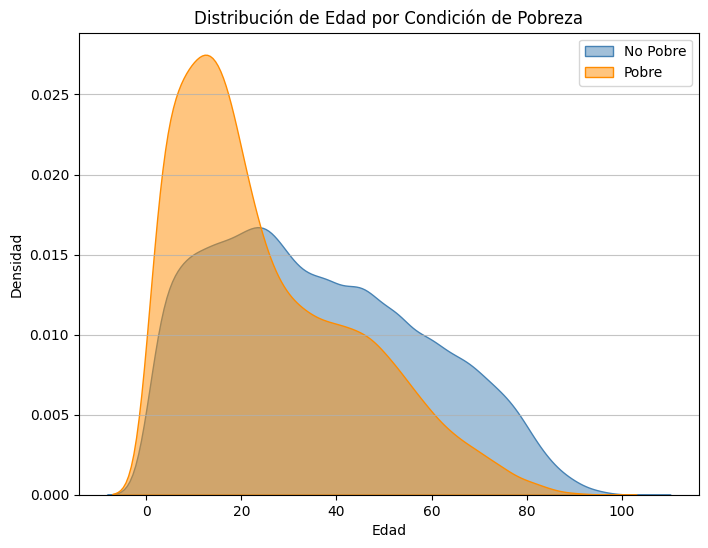

In [154]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'pobre' is the column for poverty status (1 for poor, 0 for non-poor)
# and 'CH06' is the column for age.
poverty_column = 'pobre'
age_column = 'CH06'

# Filter out rows where age or poverty status are missing from the respondieron DataFrame
df_plot_kde = respondieron.dropna(subset=[age_column, poverty_column]).copy()

# Create the kernel density plot
plt.figure(figsize=(8, 6))

# Plot KDE for non-poor
subset_no_pobre = df_plot_kde[df_plot_kde[poverty_column] == 0]
if not subset_no_pobre.empty:
    sns.kdeplot(data=subset_no_pobre, x=age_column, label='No Pobre', fill=True, color='steelblue', alpha=0.5)

# Plot KDE for poor
subset_pobre = df_plot_kde[df_plot_kde[poverty_column] == 1]
if not subset_pobre.empty:
     sns.kdeplot(data=subset_pobre, x=age_column, label='Pobre', fill=True, color='darkorange', alpha=0.5)


plt.title('Distribución de Edad por Condición de Pobreza')
plt.xlabel('Edad')
plt.ylabel('Densidad')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

# 2) PUNTO 2

Cree la variable educ definida como la cantidad de años de educación.
Use inteligentemente las variables CH12, CH13 y CH14 para crearla.
Por ejemplo, si dice que el nivel más alto de educación es “Secundario”
(CH12), “Sí” finalizo este nivel (CH13) y el último año que aprobó
(CH14) fue “sexto”, entonces puede asumir que tiene educ=12, osea 12
años de educación formal. Presente una estadística descriptiva
(promedio, sd, min, p50, max) de dicha variable creada y comente


In [158]:

def crear_educ(respondieron, ch12='CH12', ch13='CH13', ch14='CH14'):
    out = respondieron.copy()

    # Normalizo a numérico y limpio códigos de no respuesta
    c12 = pd.to_numeric(out[ch12], errors='coerce')
    c13 = pd.to_numeric(out[ch13], errors='coerce')
    c14r = pd.to_numeric(out[ch14], errors='coerce')
    c14 = c14r.where(~c14r.isin([98, 99]), np.nan)  # 98/99 => NA

    # Initialize 'educ' column with NaN using .loc
    out.loc[:, 'educ'] = np.nan

    # 1 = Jardín / preescolar (no cuenta años formales)
    m = c12.eq(1)
    out.loc[m, 'educ'] = 0.0

    # 2 = Primario (0–6 si no finalizó; 6 si finalizó)
    m = c12.eq(2)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 6.0, np.clip(c14[m], 0, 6))

    # 3 = EGB (0–9; 9 si finalizó)
    m = c12.eq(3)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 9.0, np.clip(c14[m], 0, 9))

    # 4 = Secundario (base 6 del primario + 0–6; 12 si finalizó)
    m = c12.eq(4)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 12.0, 6 + np.clip(c14[m], 0, 6))

    # 5 = Polimodal (base 9 de EGB + 0–3; 12 si finalizó)
    m = c12.eq(5)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 12.0, 9 + np.clip(c14[m], 0, 3))

    # 6 = Terciario (12 + 0–4 aprox.; 15 si finalizó)
    m = c12.eq(6)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 15.0, 12 + np.clip(c14[m], 0, 4))

    # 7 = Universitario (12 + 0–7 aprox.; 17 si finalizó)
    m = c12.eq(7)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 17.0, 12 + np.clip(c14[m], 0, 7))

    # 8 = Posgrado (17 + 0–4 aprox.; 19 si finalizó)
    m = c12.eq(8)
    out.loc[m, 'educ'] = np.where(c13[m].eq(1), 19.0, 17 + np.clip(c14[m], 0, 4))

    # 9 = Educación especial → dejamos años aprobados (cap a 12)
    m = c12.eq(9)
    out.loc[m, 'educ'] = np.clip(c14[m], 0, 12)

    # Estadística descriptiva
    stats = (out['educ']
             .dropna()
             .agg(['mean','std','min','median','max'])
             .rename({'mean':'promedio','std':'sd','median':'p50'}))

    return out, stats

# Uso:
# respondieron, resumen = crear_educ(respondieron)   # renombrá respondieron por tu DataFrame
# print(resumen)

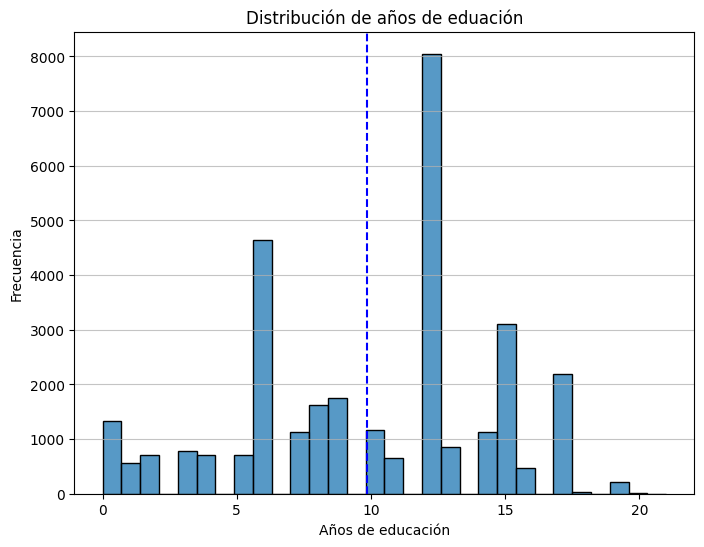


Descriptive statistics for the 'educ' variable:


,educ
promedio,9.857609
sd,4.620275
min,0.000000
p50,12.000000
max,21.000000


In [159]:

respondieron, resumen_educ = crear_educ(respondieron)


# histograma de años de educacion
plt.figure(figsize=(8, 6))
sns.histplot(data=respondieron, x='educ', bins=30)

plt.title('Distribución de años de eduación')
plt.xlabel('Años de educación')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.75)

educ_promedio=respondieron["educ"].mean()
plt.axvline(x=educ_promedio, color='blue', linestyle='--', label=f"Años de educación promedio = {educ_promedio:.2f}")

plt.show()

# Display the descriptive statistics generated by the crear_educ function
print("\nDescriptive statistics for the 'educ' variable:")
display(resumen_educ)

In [160]:

print("Sample of respondieron with the new 'educ' column:")
display(respondieron[['CH12', 'CH13', 'CH14', 'educ']].sample(10))

Sample of respondieron with the new 'educ' column:


,CH12,CH13,CH14,educ
7235,<NA>,<NA>,NaN,NaN
35308,<NA>,<NA>,3.0,NaN
5086,0,0,NaN,NaN
61631,6,1,NaN,15.0
72272,4,2,1.0,7.0
5817,<NA>,<NA>,4.0,NaN
42616,<NA>,<NA>,NaN,NaN
69244,4,1,NaN,12.0
57860,4,1,NaN,12.0
3260,0,0,NaN,NaN


In [161]:
# Select rows where the 'pobre' column is 1 (poor) and display a random sample
display(respondieron[respondieron["pobre"] == 1].sample())

,ADECCFR,ADECIFR,ADECINDR,ADECOCUR,AGLOMERADO,ANO4,CAT_INAC,CAT_OCUP,CH03,CH04,...,V5_M,V8_M,V9_M,edad2,respondio_ITF,adulto_equiv,ad_equiv_hogar,ingreso_necesario,pobre,educ
3839,1,4,0,<NA>,<NA>,2005,0,0,<NA>,2,...,0.0,0,0,441,1,0.76,8.05,1650.8135,1,NaN


# 3) PUNTO 3
Actualice la variable ingreso_total_familiar con el total de ingresos
habituales (ITF). Recuerde que los pesos de 2005 tienen un poder de
compra distinto a los pesos de 2025 en el primer trimestre. Convierta
primero los ingresos de 2005 a pesos de 2025. Similar al ítem 1, presente
en un panel A, un histograma de la variable ingreso_total_familiar y las
distribuciones de kernels para pobres y no pobres en un panel B.
Comente brevemente la distribución de ingresos en estos dos panels (3-4
oraciones). En cada panel, sume una linea vertical con la línea de la
pobreza calculada en el TP1.

In [ ]:
#Se utilizó como deflactor la Canasta Básica Total (CBT) por adulto equivalente, cuyo valor en el primer trimestre de 2005 fue de $205,07 y en el primer trimestre de 2025 ascendió a $365.177. A partir de esta información, se construyó un factor de actualización (=1781,5) esto implica que un peso de 2005 equivale aproximadamente a 1781,5 pesos de 2025. Los ingresos familiares de 2005 se multiplicaron por este factor, mientras que los de 2025 se mantuvieron sin cambios por estar ya expresados en pesos corrientes de ese año.

In [167]:

factor = 1781.5
#cambio el limite para ser pobre de 2005. ahora es la misma canasta basica para todos
linea_pobreza =  365177

# Variable de ingresos actualizada
respondieron["ingreso_total_familiar"] = respondieron["ITF"]
respondieron.loc[respondieron["ANO4"] == 2005, "ingreso_total_familiar"] *= factor

# Definir condición de pobreza
respondieron["pobre"] = np.where(respondieron["ingreso_total_familiar"] < linea_pobreza, 1, 0)

# Recortar ingresos extremos (ej: top 1%) para que se vea mejor
limite_superior = respondieron["ingreso_total_familiar"].quantile(0.99)
df_plot = respondieron[respondieron["ingreso_total_familiar"] <= limite_superior]



/tmp/ipython-input-1736313443.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1038614.5  801675.   801675.  ... 7247142.  7247142.  7247142. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  respondieron.loc[respondieron["ANO4"] == 2005, "ingreso_total_familiar"] *= factor


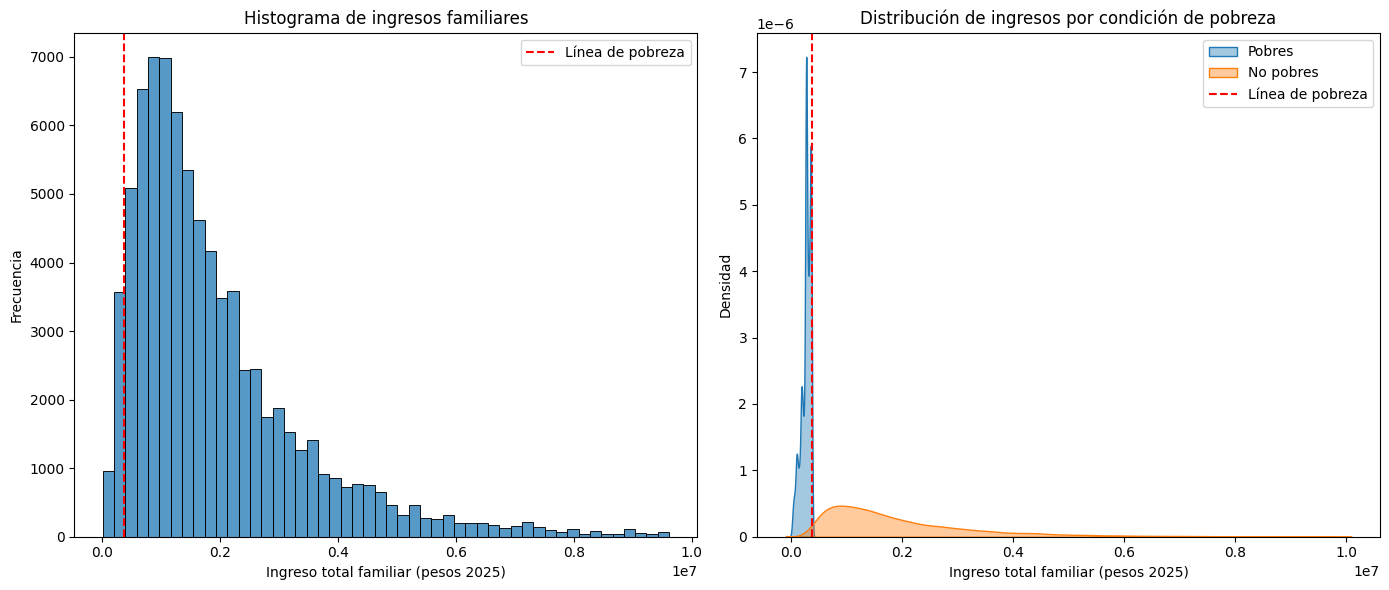

In [172]:
#graficos
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
# Histograma
sns.histplot(
    df_plot["ingreso_total_familiar"].dropna(),
    bins=50, kde=False, ax=axes[0]
)
axes[0].axvline(x=linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[0].set_title("Histograma de ingresos familiares")
axes[0].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[0].set_ylabel("Frecuencia")
axes[0].legend()

# KDE
sns.kdeplot(
    data=df_plot[df_plot["pobre"] == 1],
    x="ingreso_total_familiar", label="Pobres", fill=True, alpha=0.4, ax=axes[1]
)
sns.kdeplot(
    data=df_plot[df_plot["pobre"] == 0],
    x="ingreso_total_familiar", label="No pobres", fill=True, alpha=0.4, ax=axes[1]
)
axes[1].axvline(x=linea_pobreza, color="red", linestyle="--", label="Línea de pobreza")
axes[1].set_title("Distribución de ingresos por condición de pobreza")
axes[1].set_xlabel("Ingreso total familiar (pesos 2025)")
axes[1].set_ylabel("Densidad")
axes[1].legend()

plt.tight_layout()
plt.show()

# 4) PUNTO 4
Para el jefe del hogar, cree la variable horastrab como el total de horas
trabajadas como la suma de las horas en la ocupación principal y otras
ocupaciones (PP3E_TOT + PP3F_TOT). Presente una estadística
descriptiva (promedio, sd, min, p50, max) de dicha variable creada y
comente

In [173]:
# Crear la variable horastrab (total de horas trabajadas por el jefe del hogar)
# PP3E_TOT: Horas trabajadas en la ocupación principal
# PP3F_TOT: Horas trabajadas en otras ocupaciones
respondieron['horastrab'] = respondieron['PP3E_TOT'].fillna(0) + respondieron['PP3F_TOT'].fillna(0)

# Filtrar solo jefes de hogar (assuming CH03 == 1 indicates the head of household)
jefes = respondieron[respondieron['CH03'] == 1].copy()

# Display a sample of the new 'horastrab' column along with the original columns
print("Sample of 'horastrab', 'PP3E_TOT', and 'PP3F_TOT':")
display(jefes[["horastrab", "PP3E_TOT", "PP3F_TOT"]].sample(10))

# Present descriptive statistics for 'horastrab' for household heads
print("\nDescriptive statistics for 'horastrab' (Household Heads):")
display(jefes['horastrab'].describe().rename({'mean':'promedio','std':'sd','50%':'p50'}))

Sample of 'horastrab', 'PP3E_TOT', and 'PP3F_TOT':


,horastrab,PP3E_TOT,PP3F_TOT
65414,40.0,40.0,0.0
78692,15.0,15.0,0.0
54874,48.0,48.0,0.0
79955,81.0,54.0,27.0
67206,28.0,28.0,0.0
75932,0.0,0.0,0.0
70453,0.0,NaN,NaN
60916,64.0,56.0,8.0
74814,13.0,8.0,5.0
72555,0.0,0.0,0.0



Descriptive statistics for 'horastrab' (Household Heads):


,horastrab
count,12033.000000
promedio,22.410122
sd,27.839367
min,0.000000
25%,0.000000
p50,20.000000
75%,40.000000
max,999.000000


La variable de horas trabajadas por los jefes de hogar presenta un promedio de 22 horas semanales, con una mediana de 20 horas y un desvío estándar elevado, lo que refleja una gran dispersión. Un cuarto de los jefes no registró horas de trabajo en la semana de referencia, mientras que el 75% no supera las 40 horas. La presencia de valores extremos (por ejemplo, 999 horas) sugiere casos de no respuesta o codificación especial que deberían tratarse como datos faltantes. En conjunto, los resultados muestran la coexistencia de jefes sin empleo, con jornadas parciales y con jornadas completas.

# 5) PUNTO 5
¿Cuál es el tamaño de la de la base de datos para su región con las
variables originales unificadas? Para ello complete la tabla 1 que se le
diseña abajo y comente.

In [176]:
# REGION 44
resp44 = respondieron[respondieron['REGION'] == 44].copy()

print("Tamaño de la base de datos para Patagonia: ", resp44.shape)

display(resp44.head())

Tamaño de la base de datos para Patagonia:  (4157, 252)


,ADECCFR,ADECIFR,ADECINDR,ADECOCUR,AGLOMERADO,ANO4,CAT_INAC,CAT_OCUP,CH03,CH04,...,V9_M,edad2,respondio_ITF,adulto_equiv,ad_equiv_hogar,ingreso_necesario,pobre,educ,ingreso_total_familiar,horastrab
46625,2,2,4,3,31,2025,0,3,1,2,...,0,2304,1,0.76,2.49,909.29073,0,17.0,800000.0,35.0
46626,2,2,0,0,31,2025,3,0,3,1,...,0,289,1,1.04,2.49,909.29073,0,11.0,800000.0,0.0
46627,2,2,0,0,31,2025,3,0,3,1,...,0,81,1,0.69,2.49,909.29073,0,3.0,800000.0,0.0
46628,6,2,3,3,31,2025,0,2,1,1,...,0,1521,1,1.00,1.00,365.17700,0,9.0,745000.0,48.0
46629,8,4,6,7,31,2025,0,3,1,2,...,0,1296,1,0.77,0.77,281.18629,0,12.0,1200000.0,45.0


In [178]:
# METRICAS

# Group by year
grouped_by_year = respondieron.groupby('ANO4')

# Initialize a dictionary to store the results
yearly_metrics = {}

for year, group in grouped_by_year:
    yearly_metrics[year] = {}

    # Cantidad observaciones
    yearly_metrics[year]['Cantidad observaciones'] = group.shape[0]

    # Cantidad de observaciones con NAs en la variable “Pobre”
    yearly_metrics[year]['Cantidad de observaciones con NAs en la variable “Pobre”'] = group['pobre'].isna().sum()

    # Cantidad de Pobres
    yearly_metrics[year]['Cantidad de Pobres'] = group['pobre'].eq(1).sum()

    # Cantidad de No Pobres
    yearly_metrics[year]['Cantidad de No Pobres'] = group['pobre'].eq(0).sum()

# Convert results to a DataFrame for better display
yearly_metrics_df = pd.DataFrame(yearly_metrics).T

# Calculate totals
total_observations = yearly_metrics_df['Cantidad observaciones'].sum()
total_nas = yearly_metrics_df['Cantidad de observaciones con NAs en la variable “Pobre”'].sum()
total_poor = yearly_metrics_df['Cantidad de Pobres'].sum()
total_non_poor = yearly_metrics_df['Cantidad de No Pobres'].sum()

# Add a 'Total' row to the DataFrame
yearly_metrics_df.loc['Total'] = [total_observations, total_nas, total_poor, total_non_poor]


print("Yearly Metrics:")
display(yearly_metrics_df)

Yearly Metrics:


,Cantidad observaciones,Cantidad de observaciones con NAs en la variable “Pobre”,Cantidad de Pobres,Cantidad de No Pobres
2005,46592,0,2222,44370
2025,33372,0,1901,31471
Total,79964,0,4123,75841


# *PARTE II*: Metodos no supervisados
solo necesita utilizar las variables: edad, edad2, educ,
ingreso_total_familiar (ITF), el número de miembros en el hogar
(2005=IX_TOT y 2025=IX_Tot) y horastrab.

# 1) PUNTO 1
Realice una matriz de correlaciones con estos seis predictores para su
región y comente los resultados.

Advertencia: Las siguientes columnas requeridas faltan en los datos filtrados: ['IX_TOT']
Primeras 5 filas del DataFrame 'patagonia':


,Edad,Edad al cuadrado,Años Educación,Ingreso Familiar,Horas Trabajadas
46625,48,2304,17.0,800000,35.0
46626,17,289,11.0,800000,0.0
46627,9,81,3.0,800000,0.0
46628,39,1521,9.0,745000,48.0
46629,36,1296,12.0,1200000,45.0


Dimensiones del DataFrame 'patagonia': (4010, 5)


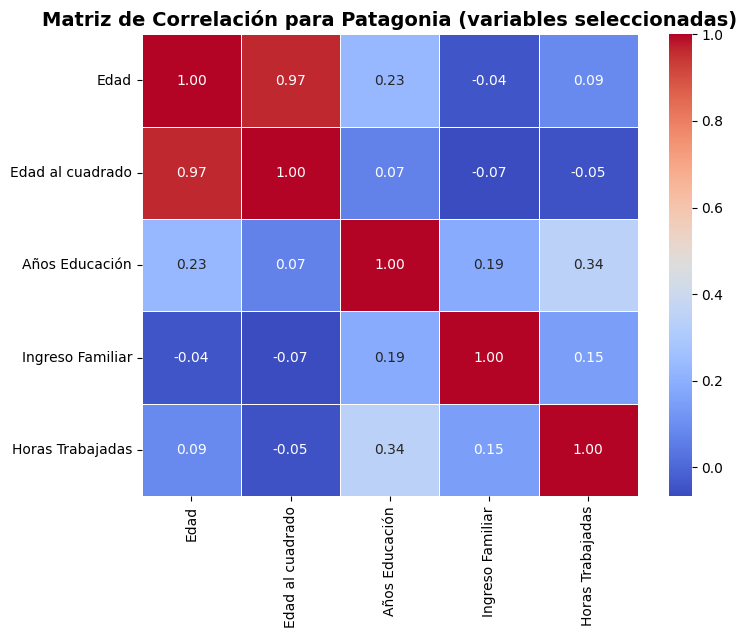

Matriz de Correlación para Patagonia:


,Edad,Edad al cuadrado,Años Educación,Ingreso Familiar,Horas Trabajadas
Edad,1.000000,0.966591,0.229483,-0.043227,0.088578
Edad al cuadrado,0.966591,1.000000,0.069778,-0.066569,-0.052204
Años Educación,0.229483,0.069778,1.000000,0.185300,0.342918
Ingreso Familiar,-0.043227,-0.066569,0.185300,1.000000,0.149522
Horas Trabajadas,0.088578,-0.052204,0.342918,0.149522,1.000000


In [181]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Filtrar el DataFrame principal (respondieron) para la REGION 44
patagonia_filtered = respondieron[respondieron['REGION'] == 44].copy()

# Asegurar que las columnas necesarias existan antes de seleccionar
# Columnas requeridas para el análisis
required_cols = ['CH06', 'edad2', 'educ', 'ITF', 'IX_TOT', 'horastrab']
missing_cols = [col for col in required_cols if col not in patagonia_filtered.columns]

if missing_cols:
    print(f"Advertencia: Las siguientes columnas requeridas faltan en los datos filtrados: {missing_cols}")
    # Intentar continuar con las columnas disponibles, o manejar según sea necesario
    available_cols = [col for col in required_cols if col in patagonia_filtered.columns]
    patagonia = patagonia_filtered[available_cols].dropna().copy()
else:
    # Crear el nuevo DataFrame 'patagonia' con las columnas especificadas y eliminar NaNs
    patagonia = patagonia_filtered[required_cols].dropna().copy()

# Diccionario para renombrar columnas en el gráfico para mayor claridad
rename_dict = {
    'CH06': 'Edad',
    'edad2': 'Edad al cuadrado',
    'educ': 'Años Educación',
    'ITF': 'Ingreso Familiar',
    'IX_TOT': 'Miembros Hogar',
    'horastrab': 'Horas Trabajadas'
}
# Solo intentar renombrar si la columna original existe en el dataframe después de dropna
rename_dict = {k: v for k, v in rename_dict.items() if k in patagonia.columns}
patagonia.rename(columns=rename_dict, inplace=True)

# Mostrar las primeras 5 filas del DataFrame 'patagonia'
print("Primeras 5 filas del DataFrame 'patagonia':")
display(patagonia.head())

print("Dimensiones del DataFrame 'patagonia':", patagonia.shape)

# Calcular la matriz de correlación para el DataFrame 'patagonia'
correlation_matrix_patagonia = patagonia.corr()

# Mostrar la matriz de correlación usando un mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_patagonia, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Matriz de Correlación para Patagonia (variables seleccionadas)', fontsize=14, weight='bold')
plt.show()

print("Matriz de Correlación para Patagonia:")
display(correlation_matrix_patagonia)

In [ ]:
#2

In [185]:
# Muestra cuales son los componentes mas importantes
if 'pca' not in locals():
    print("Error: The 'pca' object does not exist. Please run the PCA code in the previous cell first.")
else:
    # Display the principal components (loadings)
    # Assuming the required columns for PCA are known
    required_cols_pca = ['edad', 'edad2', 'educ', 'ITF', 'miembros_hogar', 'horastrab']
    components_df = pd.DataFrame(patagonia_filtered.components_, columns=required_cols_pca, index=['PC1', 'PC2'])

    print("Principal Components (Loadings):")
    display(components_df)

Error: The 'pca' object does not exist. Please run the PCA code in the previous cell first.


In [186]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import pandas as pd

# Ensure the 'patagonia' DataFrame exists and has the required columns
# Assuming 'patagonia' was created and cleaned in the previous steps
required_cols_pca = ['Edad', 'Edad al cuadrado', 'Años Educación', 'Ingreso Familiar', 'Miembros Hogar', 'Horas Trabajadas']

if 'patagonia' not in locals() or not all(col in patagonia.columns for col in required_cols_pca):
    print("Error: The 'patagonia' DataFrame does not exist or is missing required columns for PCA.")
    print("Please run the previous steps to create and prepare the 'patagonia' DataFrame with columns:", required_cols_pca)
else:
    # Select the variables for PCA from the 'patagonia' DataFrame
    pca_variables = patagonia_filtered[required_cols_pca].copy()

    # Standardize the data
    scaler = StandardScaler()
    pca_variables_scaled = scaler.fit_transform(pca_variables)

    # Apply PCA
    # We'll calculate all components for now to analyze explained variance later (Punto 4)
    pca = PCA(n_components=len(required_cols_pca))
    pca.fit(pca_variables_scaled)

    print("PCA analysis completed.")
    # The 'pca' object is now available for further analysis (e.g., displaying components)

Error: The 'patagonia' DataFrame does not exist or is missing required columns for PCA.
Please run the previous steps to create and prepare the 'patagonia' DataFrame with columns: ['Edad', 'Edad al cuadrado', 'Años Educación', 'Ingreso Familiar', 'Miembros Hogar', 'Horas Trabajadas']


In [ ]:
#3


In [183]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure the 'pca' object and 'pca_variables' (used for column names) exist
if 'pca' not in locals() or 'pca_variables' not in locals():
    print("Error: PCA results not available. Please run the PCA code first.")
else:
    # Get the loadings (components) and variable names
    loadings = pca.components_
    variables = pca_variables.columns

    # Create the plot
    fig, ax = plt.subplots(figsize=(10, 10))

    # Plot arrows for each variable
    arrow_scale = 1.0 # Adjust this scale factor as needed for better visualization
    text_offset = 0.05 # Small offset to move text away from arrow tip

    for i, var in enumerate(variables):
        # Multiply the loading by the square root of the explained variance to scale the arrows
        # This is a common practice in biplots to represent the contribution of variables
        ax.arrow(0, 0, loadings[0, i] * arrow_scale, loadings[1, i] * arrow_scale,
                 head_width=0.05, head_length=0.1, fc='red', ec='red', length_includes_head=True)

        # Apply a specific offset for 'miembros_hogar' if needed to avoid overlap
        x_offset = loadings[0, i] * arrow_scale * (1 + np.sign(loadings[0, i]) * text_offset)
        y_offset = loadings[1, i] * arrow_scale * (1 + np.sign(loadings[1, i]) * text_offset)

        if var == 'miembros_hogar':
             # Adjust offset specifically for 'miembros_hogar'
             x_offset = loadings[0, i] * arrow_scale * 1.15 # Increase horizontal offset
             y_offset = loadings[1, i] * arrow_scale * (1 + np.sign(loadings[1, i]) * text_offset)


        # Add text label with increased font size and slight offset
        ax.text(x_offset, y_offset, var, color='blue', fontsize=12, ha='center', va='center')


    # Set plot limits
    # Adjust limits based on arrow scale to ensure all arrows and text are visible
    max_loading = np.max(np.abs(loadings)) * arrow_scale * 1.2 # Add some padding
    ax.set_xlim([-max_loading, max_loading])
    ax.set_ylim([-max_loading, max_loading])


    # Add labels and title
    ax.set_xlabel(f'Principal Component 1 (explains {pca.explained_variance_ratio_[0]:.2%})')
    ax.set_ylabel(f'Principal Component 2 (explains {pca.explained_variance_ratio_[1]:.2%})')
    ax.set_title('PCA Loadings Plot (PC1 vs PC2)', fontsize=14, weight='bold')

    # Add grid and center axes
    ax.grid()
    ax.axhline(0, color='grey', lw=1)
    ax.axvline(0, color='grey', lw=1)

    plt.show()

Error: PCA results not available. Please run the PCA code first.


**Comentario sobre los pesos (loadings) de PCA:**

El gráfico de flechas muestra la dirección y magnitud con la que cada variable original contribuye a los dos primeros componentes principales.

*   **PC1:** Las flechas de 'edad' y 'edad2' apuntan fuertemente en la misma dirección positiva a lo largo del eje PC1, mientras que 'miembros_hogar' apunta en la dirección opuesta (negativa). Esto confirma que PC1 captura la relación entre la edad (y su cuadrado) y el tamaño del hogar. Individuos de mayor edad tienden a tener valores más altos en PC1, y hogares con menos miembros también.

*   **PC2:** Las flechas de 'educ', 'ITF' y 'horastrab' apuntan en direcciones positivas a lo largo del eje PC2. 'ITF' y 'horastrab' tienen pesos relativamente altos y apuntan en direcciones similares, lo que sugiere que ambas variables están relacionadas con este componente. 'educ' también contribuye a PC2. Este componente parece estar asociado con aspectos socioeconómicos relacionados con los ingresos, la educación y la actividad laboral.

La longitud de las flechas indica la importancia de la variable en ese componente. Las variables con flechas más largas tienen una mayor influencia en la definición del componente. La dirección de las flechas indica la correlación entre la variable original y el componente principal. Flechas que apuntan en direcciones similares tienen correlaciones positivas con el componente, mientras que las que apuntan en direcciones opuestas tienen correlaciones negativas.

**Comentario sobre los pesos (loadings) de PCA:**

El gráfico de flechas muestra la dirección y magnitud con la que cada variable original contribuye a los dos primeros componentes principales.

*   **PC1:** Las flechas de 'edad' y 'edad2' apuntan fuertemente en la misma dirección positiva a lo largo del eje PC1, mientras que 'miembros_hogar' apunta en la dirección opuesta (negativa). Esto confirma que PC1 captura la relación entre la edad (y su cuadrado) y el tamaño del hogar. Individuos de mayor edad tienden a tener valores más altos en PC1, y hogares con menos miembros también.

*   **PC2:** Las flechas de 'educ', 'ITF' y 'horastrab' apuntan en direcciones positivas a lo largo del eje PC2. 'ITF' y 'horastrab' tienen pesos relativamente altos y apuntan en direcciones similares, lo que sugiere que ambas variables están relacionadas con este componente. 'educ' también contribuye a PC2. Este componente parece estar asociado con aspectos socioeconómicos relacionados con los ingresos, la educación y la actividad laboral.

La longitud de las flechas indica la importancia de la variable en ese componente. Las variables con flechas más largas tienen una mayor influencia en la definición del componente. La dirección de las flechas indica la correlación entre la variable original y el componente principal. Flechas que apuntan en direcciones similares tienen correlaciones positivas con el componente, mientras que las que apuntan en direcciones opuestas tienen correlaciones negativas.

In [ ]:
#4 es hacer un grafique la proporción de la varianza explicada para cada uno de los seis componentes

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the 'patagonia' DataFrame exists and has the required columns
# Assuming 'patagonia' was created and cleaned in the previous steps
required_cols_pca = ['edad', 'edad2', 'educ', 'ITF', 'miembros_hogar', 'horastrab']

if 'patagonia' not in locals() or not all(col in patagonia.columns for col in required_cols_pca):
    print("Error: The 'patagonia' DataFrame does not exist or is missing required columns for PCA.")
    print("Please run the previous steps to create and prepare the 'patagonia' DataFrame with columns:", required_cols_pca)
else:
    # Select the variables for PCA from the 'patagonia' DataFrame
    pca_variables = patagonia[required_cols_pca].copy()

    # Standardize the data
    scaler = StandardScaler()
    pca_variables_scaled = scaler.fit_transform(pca_variables)

    # Apply PCA to get all 6 components
    pca_full = PCA(n_components=len(required_cols_pca))
    pca_full.fit(pca_variables_scaled)

    # Get the explained variance ratio for each component
    explained_variance_ratio = pca_full.explained_variance_ratio_

    # Create a bar plot of the explained variance ratio
    plt.figure(figsize=(8, 6))
    plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio)
    plt.xlabel('Principal Component')
    plt.ylabel('Proportion of Variance Explained')
    plt.title('Explained Variance Ratio by Principal Component')
    plt.xticks(range(1, len(explained_variance_ratio) + 1))
    plt.grid(axis='y', alpha=0.75)
    plt.show()

    # Optionally, display the explained variance ratio values
    print("Explained Variance Ratio for each component:")
    for i, ratio in enumerate(explained_variance_ratio):
        print(f"PC{i+1}: {ratio:.4f}")

    # Optionally, display the cumulative explained variance
    cumulative_explained_variance = explained_variance_ratio.cumsum()
    print("\nCumulative Explained Variance:")
    for i, cumulative_ratio in enumerate(cumulative_explained_variance):
        print(f"PC1 to PC{i+1}: {cumulative_ratio:.4f}")

In [ ]:
#B cluster osea e 5

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure the 'patagonia' DataFrame exists and has the required columns
# Assuming 'patagonia' was created and cleaned in the previous steps
required_cols_clustering = ['edad', 'ITF'] # Variables for plotting
clustering_variables = ['edad', 'edad2', 'educ', 'ITF', 'miembros_hogar', 'horastrab'] # Variables for clustering


if 'patagonia' not in locals() or not all(col in patagonia.columns for col in clustering_variables):
    print("Error: The 'patagonia' DataFrame does not exist or is missing required columns for clustering.")
    print("Please run the previous steps to create and prepare the 'patagonia' DataFrame with columns:", clustering_variables)
else:
    # Select the variables for clustering and standardize them
    X = patagonia[clustering_variables].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Define the values of k to test
    k_values = [2, 4, 10]

    # Store clustering results and plots
    clustering_results = {}

    for k in k_values:
        print(f"\nRunning K-Means with k = {k}")
        # Apply K-Means clustering
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=20) # Use n_init=20 as requested
        cluster_labels = kmeans.fit_predict(X_scaled)

        # Add 1 to cluster labels so they start from 1 instead of 0
        cluster_labels = cluster_labels + 1

        # Add cluster labels to the original patagonia DataFrame (or a copy for plotting)
        # Create a copy to avoid modifying the original 'patagonia' in place repeatedly
        patagonia_clustered = patagonia.copy()
        patagonia_clustered[f'cluster_k{k}'] = cluster_labels

        # Store results
        clustering_results[k] = {
            'labels': cluster_labels,
            'model': kmeans,
            'data': patagonia_clustered # Store the dataframe with labels
        }

        # Create a scatter plot of edad vs ITF, colored by cluster using a categorical palette
        plt.figure(figsize=(8, 6))
        sns.scatterplot(data=patagonia_clustered, x='edad', y='ITF', hue=f'cluster_k{k}', palette='tab10', legend='full', alpha=0.6) # Changed palette to 'tab10'
        plt.title(f'K-Means Clustering (k={k}): Edad vs ITF', fontsize=14, weight='bold')
        plt.xlabel('Edad', fontsize=12)
        plt.ylabel('Ingreso Total Familiar (ITF)', fontsize=12)
        plt.yscale('log') # Use log scale for ITF for better visualization
        plt.grid(True)
        plt.show()

    # Now, add a markdown cell for interpretation

In [ ]:
#5b)

In [ ]:
#6

In [ ]:
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
import matplotlib.pyplot as plt
import pandas as pd

# Ensure the 'patagonia' DataFrame exists and has the required columns
# Assuming 'patagonia' was created and cleaned in the previous steps
clustering_variables = ['edad', 'edad2', 'educ', 'ITF', 'miembros_hogar', 'horastrab']

if 'patagonia' not in locals() or not all(col in patagonia.columns for col in clustering_variables):
    print("Error: The 'patagonia' DataFrame does not exist or is missing required columns for hierarchical clustering.")
    print("Please run the previous steps to create and prepare the 'patagonia' DataFrame with columns:", clustering_variables)
else:
    # Select the variables for clustering and standardize them
    X = patagonia[clustering_variables].copy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Perform hierarchical clustering using the 'ward' linkage method
    linked = linkage(X_scaled, 'ward')

    # --- First Dendrogram: Full dendrogram without a cut line ---
    plt.figure(figsize=(12, 8))
    dendrogram(linked,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=False)
    plt.title('Dendrograma Completo del Clustering Jerárquico para Patagonia', fontsize=14, weight='bold')
    plt.xlabel('Índice de Muestra (o Tamaño de Cluster si no se muestran hojas)', fontsize=12)
    plt.ylabel('Distancia', fontsize=12)
    plt.show()

    print("-" * 50) # Separator

    # --- Second Dendrogram: Truncated dendrogram from y=15 upwards ---
    # To truncate the dendrogram, we can use the 'truncate_mode' and 'p' parameters
    # 'lastp' mode shows the last p merged clusters
    # The number of clusters when cutting at y=15 can be found using fcluster
    max_distance = 15
    clusters_at_15 = fcluster(linked, max_distance, criterion='distance')
    num_clusters_at_15 = len(np.unique(clusters_at_15))

    # We want to show the dendrogram above y=15, which means showing the fusions that result in a smaller number of clusters
    # The number of levels to show from the top can be related to the number of clusters formed at a certain height.
    # A simpler way to visualize above a certain height is to manually set the y-axis limits.
    plt.figure(figsize=(12, 8))
    dendrogram(linked,
               orientation='top',
               distance_sort='descending',
               show_leaf_counts=False)

    plt.ylim(15, linked[:, 2].max() * 1.1) # Set y-axis limits from 15 upwards
    plt.title('Dendrograma del Clustering Jerárquico para Patagonia (Distancia >= 15)', fontsize=14, weight='bold')
    plt.xlabel('Índice de Muestra (o Tamaño de Cluster si no se muestran hojas)', fontsize=12)
    plt.ylabel('Distancia', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
#7